In [2]:
from google.colab import files

uploaded = files.upload()

Saving student_performance_1000.xlsx to student_performance_1000 (1).xlsx


In [3]:
import pandas as pd

df = pd.read_excel('student_performance_1000.xlsx')
df.head()

,Student_ID,Name,Class,Maths,Science,English,Computer
0,S0001,Surya1,CSE-B,49,36,93,86
1,S0002,Ishita2,CSE-A,37,94,61,73
2,S0003,Karthik3,IT-A,100,37,59,78
3,S0004,Lavanya4,CSE-C,36,36,80,97
4,S0005,Yash5,CSE-A,88,63,78,38


In [4]:
print(df.shape)

(1000, 7)


In [5]:
(1000,7)

(1000, 7)

In [6]:
df['Average'] = df[['Maths','Science','English','Computer']].mean(axis=1)
df.head()

,Student_ID,Name,Class,Maths,Science,English,Computer,Average
0,S0001,Surya1,CSE-B,49,36,93,86,66.00
1,S0002,Ishita2,CSE-A,37,94,61,73,66.25
2,S0003,Karthik3,IT-A,100,37,59,78,68.50
3,S0004,Lavanya4,CSE-C,36,36,80,97,62.25
4,S0005,Yash5,CSE-A,88,63,78,38,66.75


In [7]:
top10 = df.sort_values('Average', ascending=False).head(10)
print(top10[['Name','Average']])

          Name  Average
319   Pooja320    95.75
244   Surya245    91.75
702   Sneha703    90.75
402  Harini403    90.50
424   Aarav425    90.50
698    Yash699    89.75
353  Ananya354    89.50
660   Nisha661    89.50
852   Kavin853    89.25
568   Rahul569    89.00


In [8]:
df['Average'] = df[['Maths','Science','English','Computer']].mean(axis=1)

In [9]:
def grade(avg):
    if avg >= 90:
        return 'A'
    elif avg >= 75:
        return 'B'
    elif avg >= 60:
        return 'C'
    elif avg >= 50:
        return 'D'
    else:
        return 'F'

df['Grade'] = df['Average'].apply(grade)

In [10]:
df['Status'] = df[['Maths','Science','English','Computer']].apply(
    lambda x: 'Pass' if all(x >= 40) else 'Fail',
    axis=1
)

In [11]:
topper = df.loc[df['Average'].idxmax()]
print(topper)

Student_ID       S0320
Name          Pooja320
Class            CSE-A
Maths              100
Science             93
English             90
Computer           100
Average          95.75
Grade                A
Status            Pass
Name: 319, dtype: object


In [12]:
top10 = df.sort_values('Average', ascending=False).head(10)
print(top10[['Name','Average','Grade']])

          Name  Average Grade
319   Pooja320    95.75     A
244   Surya245    91.75     A
702   Sneha703    90.75     A
402  Harini403    90.50     A
424   Aarav425    90.50     A
698    Yash699    89.75     B
353  Ananya354    89.50     B
660   Nisha661    89.50     B
852   Kavin853    89.25     B
568   Rahul569    89.00     B


In [13]:
print(df[['Maths','Science','English','Computer']].mean())

Maths       66.711
Science     65.857
English     67.548
Computer    67.853
dtype: float64


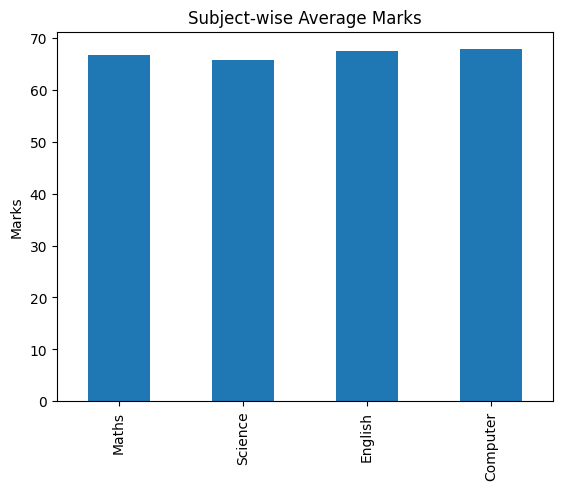

In [14]:
import matplotlib.pyplot as plt

subject_avg = df[['Maths','Science','English','Computer']].mean()

subject_avg.plot(kind='bar')
plt.title('Subject-wise Average Marks')
plt.ylabel('Marks')
plt.show()

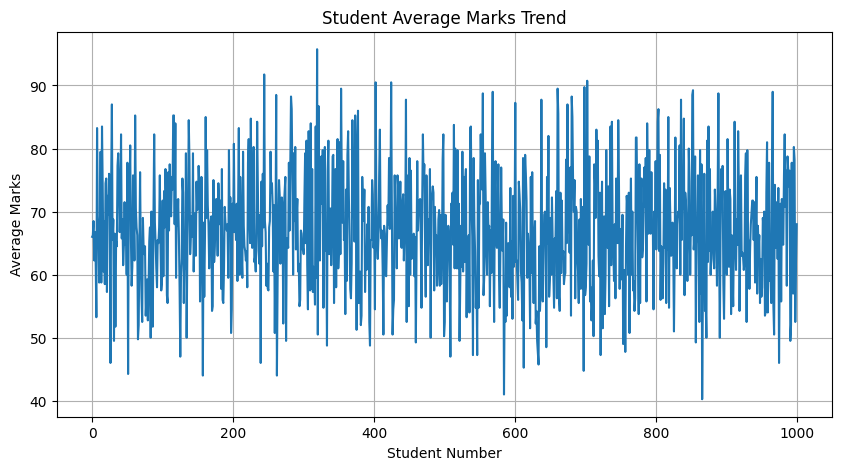

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df.index, df['Average'])

plt.title('Student Average Marks Trend')
plt.xlabel('Student Number')
plt.ylabel('Average Marks')
plt.grid(True)

plt.show()

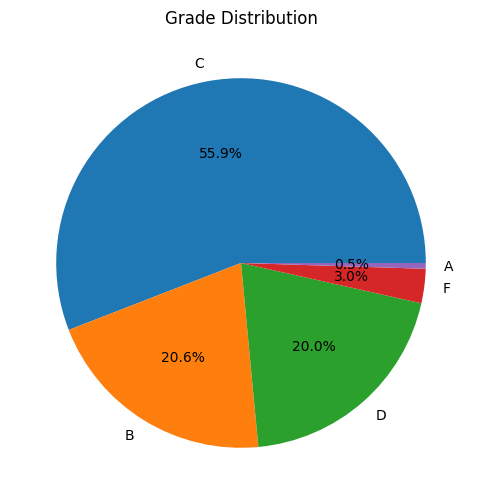

In [17]:
import matplotlib.pyplot as plt

grade_count = df['Grade'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(grade_count,
        labels=grade_count.index,
        autopct='%1.1f%%')

plt.title('Grade Distribution')
plt.show()